In [17]:
import os, pathlib
os.chdir("/Users/gregcc/Documents/GitHub/SURP25/Microlensing")
import ML_amber, inspect, sys, importlib

from astropy.io import ascii
import matplotlib.pyplot as plt
import numpy as np
print("Imported ML.py from:", ML_amber.__file__)

Imported ML.py from: /Users/gregcc/Documents/GitHub/SURP25/Microlensing/ML_amber.py


In [18]:
from ML_amber import ThreeLens1S
from ML_amber import TwoLens1S

In [19]:
#parameters from Liebig, et al; (2010)
q2 = 1e-3
q3 = 1e-5
s2 = 1.3
s3 = 1.3003845585056752
psi = 1.393457227228705
q4 = q3 + q2 #for binary system
u0_list =[0.0155] #paper

u0_list_n = [-0.0155]

t0 = 0
tE = 20
rho = 1.8e-3
rs = rho

secnum = 45
basenum = 2
num_points = 100

#paper
D_l = 6 #kpc
D_s = 8 #kpc

m1 = 0.3 #Lens Star Mass (Solar Mass)

In [20]:
def Einstein_Radius(M_solar, D_l_kpc, D_s_kpc):
    """
    Computes the Einstein Radius.

    Parameters:
    M_solar : float
        Mass of the lens in Solar masses
    D_l_kpc : float
        Distance to the lens in kpc
    D_s_kpc : float
        Distance to the source in kpc

    Returns:
    R_E : float
        Einstein radius in meters
    theta_E_arcsec : float
        Einstein radius in arcseconds
    theta_E_mas : float
        Einstein radius in milliarcseconds
    """
    # Constants
    c = 3e8            # speed of light in m/s
    G = 6.674e-11      # gravitational constant in N m^2 / kg^2
    M_sun = 1.989e30   # kg
    kpc_to_m = 3.086e19  # meters
    rad_to_arcsec = 206265  # arcsec per radian

    # Convert inputs
    M = M_solar * M_sun
    D_l = D_l_kpc * kpc_to_m
    D_s = D_s_kpc * kpc_to_m
    D_ls = D_s - D_l

    # Einstein radius in meters
    R_E = ((4 * G * M / c**2) * (D_ls * D_l / D_s)) ** 0.5

    # Angular Einstein radius in radians
    theta_E_rad = R_E / D_l

    # Convert to arcsec and mas
    theta_E_arcsec = theta_E_rad * rad_to_arcsec
    theta_E_mas = theta_E_arcsec * 1000

    return R_E, theta_E_arcsec, theta_E_mas

In [21]:
R_E, theta_E_arcsec, theta_E_mas = Einstein_Radius(m1, D_l, D_s)

print(f"Einstein Radius: {R_E:.2e} m")
print(f"Angular Einstein Radius: {theta_E_arcsec:.4f} arcsec")
print(f"Angular Einstein Radius: {theta_E_mas:.2f} mas")

Einstein Radius: 2.86e+11 m
Angular Einstein Radius: 0.0003 arcsec
Angular Einstein Radius: 0.32 mas


In [22]:
#triple system
triple_model = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3, 0, psi, rs, secnum, basenum, num_points)

param = [
    np.log(triple_model.s2), np.log(triple_model.q2), triple_model.u0_list[0], triple_model.alpha_deg,
    np.log(triple_model.rho), np.log(triple_model.tE), triple_model.t0,
    np.log(triple_model.s3), np.log(triple_model.q3), triple_model.psi_rad
]
mag, *_ = triple_model.VBM.TripleLightCurve(param, triple_model.highres_t)

triple_model_tau = triple_model.highres_tau
triple_model_mag = mag

In [23]:
import numpy as np

# --- 1) Moon orbit projected on sky (planet is the origin) ---
def moon_xy_rel(
    t_days,
    P_days=30.0,     # moon period (set ~30 for "one month")
    r_pm=0.01,       # planet–moon semi-major axis in theta_E
    i_deg=30.0,      # inclination (0 face-on)
    Omega_deg=0.0,   # ascending node
    e=0.0,           # eccentricity
    t_peri=0.0,      # pericenter epoch
):
    i   = np.deg2rad(i_deg)
    Om  = np.deg2rad(Omega_deg)

    # circular default
    M   = 2*np.pi*((t_days - t_peri)/P_days % 1.0)
    xop = r_pm*np.cos(M)         # orbital plane coords with ω=0
    yop = r_pm*np.sin(M)

    # rotate by node and inclination into sky plane (standard convention)
    cosO, sinO, cosi = np.cos(Om), np.sin(Om), np.cos(i)
    x1, y1 = xop, yop
    x_rel =  cosO*x1 - sinO*(y1*cosi)
    y_rel =  sinO*x1 + cosO*(y1*cosi)
    return x_rel, y_rel

# --- 2) Build time-varying s3(t), psi(t) from (x_rel,y_rel) and fixed s2 ---
def star_moon_from_rel(x_rel, y_rel, s2):
    x_star_moon = s2 + x_rel
    y_star_moon = y_rel
    s3_t  = np.hypot(x_star_moon, y_star_moon)
    psi_t = np.arctan2(y_star_moon, x_star_moon)
    return s3_t, psi_t

# --- 3) Driver: stitch TripleLightCurve in blocks while updating s3, psi ---
def run_triple_with_orbit(triple_model,
                          P_days=30.0,
                          r_pm=0.01,
                          i_deg=30.0,
                          Omega_deg=0.0,
                          n_blocks=60):
    """
    Assumes triple_model.highres_t are *days* relative to t0 (your code passes it to VBM).
    We update (s3, psi) piecewise-const within each block and concatenate the outputs.
    """
    t = triple_model.highres_t
    x_rel, y_rel = moon_xy_rel(t, P_days, r_pm, i_deg, Omega_deg)
    s3_t, psi_t  = star_moon_from_rel(x_rel, y_rel, triple_model.s2)

    # Split into blocks
    idx_edges = np.linspace(0, len(t), n_blocks+1, dtype=int)
    out_mag   = np.empty_like(t, dtype=float)
    # (optionally) if you also compute astrometric centroid, prepare arrays here

    for b in range(n_blocks):
        i0, i1 = idx_edges[b], idx_edges[b+1]
        tb     = t[i0:i1]
        if tb.size == 0:
            continue

        # Freeze s3, psi within this block (use mid-point for stability)
        s3_b  = float(s3_t[(i0+i1)//2])
        psi_b = float(psi_t[(i0+i1)//2])

        # Update params and call VBM on the sub-grid
        pm = [
            np.log(triple_model.s2), np.log(triple_model.q2),
            triple_model.u0_list[0], triple_model.alpha_deg,
            np.log(triple_model.rho), np.log(triple_model.tE),
            triple_model.t0,
            np.log(s3_b), np.log(triple_model.q3), psi_b
        ]
        mag_b, *_ = triple_model.VBM.TripleLightCurve(pm, tb)
        out_mag[i0:i1] = mag_b

        # If you have a centroid/astrometry method, parallel it here using the same pm,tb

    return out_mag, (s3_t, psi_t), (x_rel, y_rel)

# ====== USAGE with your existing objects/values ======
# Example: month-long lunar orbit, ~20-day microlensing event timescale
# r_pm: If you truly want the moon at 0.01 θ_E from the planet, keep r_pm=0.01.
#       (Note: this overrides your static s3; we’re generating s3(t) on the fly.)
mag_orbit, (s3_t, psi_t), (xrel, yrel) = run_triple_with_orbit(
    triple_model,
    P_days=30.0,
    r_pm=0.01,
    i_deg=30.0,
    Omega_deg=0.0,
    n_blocks=80,          # finer blocks -> smoother, more compute
)

# Optional: keep the static run for comparison
param_static = [
    np.log(triple_model.s2), np.log(triple_model.q2), triple_model.u0_list[0], triple_model.alpha_deg,
    np.log(triple_model.rho), np.log(triple_model.tE), triple_model.t0,
    np.log(triple_model.s3), np.log(triple_model.q3), triple_model.psi_rad
]
mag_static, *_ = triple_model.VBM.TripleLightCurve(param_static, triple_model.highres_t)

# Now you can compare mag_orbit vs mag_static, and (ideally) your centroid series too.


In [24]:
def run_with_orbit_direct(VBM, t, s2, q2, u0, alpha_deg, rho, tE, t0, q3,
                          P_days=30.0, r_pm=0.01, i_deg=30.0, Omega_deg=0.0, n_blocks=80):
    xrel, yrel = moon_xy_rel(t, P_days, r_pm, i_deg, Omega_deg)
    s3_t, psi_t = star_moon_from_rel(xrel, yrel, s2)
    edges = np.linspace(0, len(t), n_blocks+1, dtype=int)
    out = np.empty_like(t, float)
    for b in range(n_blocks):
        i0, i1 = edges[b], edges[b+1]
        if i0 == i1: continue
        mid = (i0 + i1)//2
        pm = [np.log(s2), np.log(q2), u0, alpha_deg,
              np.log(rho), np.log(tE), t0,
              np.log(float(s3_t[mid])), np.log(q3), float(psi_t[mid])]
        out[i0:i1], *_ = VBM.TripleLightCurve(pm, t[i0:i1])
    return out, (s3_t, psi_t)


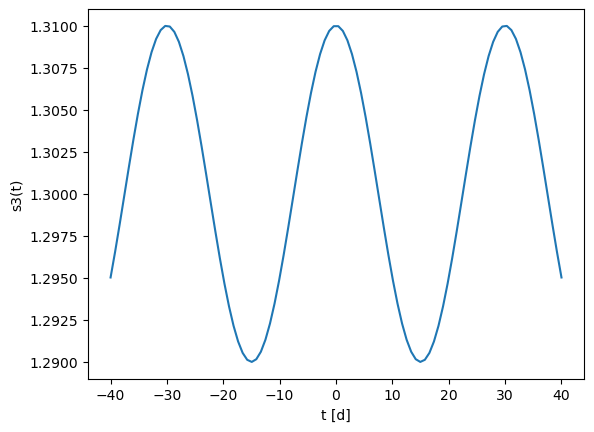

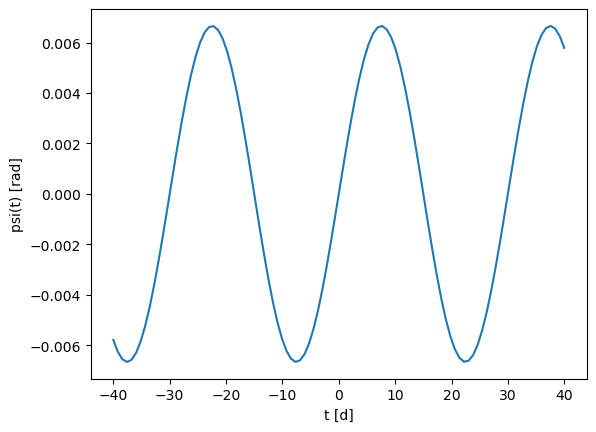

In [25]:
import matplotlib.pyplot as plt
t = triple_model.highres_t
fig,ax=plt.subplots(); ax.plot(t,s3_t); ax.set_xlabel('t [d]'); ax.set_ylabel('s3(t)'); plt.show()
fig,ax=plt.subplots(); ax.plot(t,psi_t); ax.set_xlabel('t [d]'); ax.set_ylabel('psi(t) [rad]'); plt.show()


In [26]:
import numpy as np

# --- orbit & helpers (as before) ---
def moon_xy_rel_one(t, P_days, r_pm, i_deg=30.0, Omega_deg=0.0):
    i, Om = np.deg2rad(i_deg), np.deg2rad(Omega_deg)
    M = 2*np.pi*((t)/P_days % 1.0)
    xop, yop = r_pm*np.cos(M), r_pm*np.sin(M)
    cosO, sinO, cosi = np.cos(Om), np.sin(Om), np.cos(i)
    x_rel =  cosO*xop - sinO*(yop*cosi)
    y_rel =  sinO*xop + cosO*(yop*cosi)
    return x_rel, y_rel

def s3_psi_from_rel(x_rel, y_rel, s2):
    x_star_moon = s2 + x_rel
    y_star_moon = y_rel
    s3  = np.hypot(x_star_moon, y_star_moon)
    psi = np.arctan2(y_star_moon, x_star_moon)
    return s3, psi

def source_xy(t, t0, tE, u0, alpha_deg):
    # rectilinear motion with impact parameter u0 at closest approach (t=t0)
    a = np.deg2rad(alpha_deg)
    tau = (t - t0)/tE
    # parallel unit vector (motion direction) and perpendicular unit
    e_par  = np.array([np.cos(a), np.sin(a)])
    e_perp = np.array([-np.sin(a), np.cos(a)])
    u = tau*e_par + u0*e_perp
    return u[0], u[1]

# --- YOU must implement this using your TripleLensing solver ---
# It should return arrays of image x,y and signed magnifications mu for ONE epoch.
def images_and_mus_at(xs, ys, s2, q2, s3, q3, psi, rho):
    """
    >>> x_i, y_i, mu_i = images_and_mus_at(...)
    """
    # Example skeleton (replace with your own):
    # mlens = build_lens_system(q2, q3, s2, s3, psi)  # your function/struct
    # res = sol_len_equ_cpp(mlens, z=0.0, xs=xs, ys=ys, NLENS=3)
    # xs_i, ys_i, mu_i = [], [], []
    # for root in res:
    #     ok, mu, *_ = trueSolution(mlens, 0.0, xs, ys, root, cal_ang=False)
    #     if ok and np.isfinite(mu):
    #         xs_i.append(root[0]); ys_i.append(root[1]); mu_i.append(mu)
    # return np.array(xs_i), np.array(ys_i), np.array(mu_i)
    raise NotImplementedError

# --- Per-epoch loop: moon moves AND source moves ---
def run_per_epoch_centroid(
    t_array, *, s2, q2, q3, u0, alpha_deg, rho, t0, tE,
    P_days=30.0, r_pm=0.01, i_deg=30.0, Omega_deg=0.0,
):
    n = len(t_array)
    mag = np.empty(n)
    cx  = np.empty(n)  # centroid x
    cy  = np.empty(n)  # centroid y
    s3_series  = np.empty(n)
    psi_series = np.empty(n)

    for k, tk in enumerate(t_array):
        # 1) moon geometry at tk
        xr, yr      = moon_xy_rel_one(tk, P_days, r_pm, i_deg, Omega_deg)
        s3k, psik   = s3_psi_from_rel(xr, yr, s2)
        s3_series[k], psi_series[k] = s3k, psik

        # 2) source position at tk
        xs, ys = source_xy(tk, t0, tE, u0, alpha_deg)

        # 3) image solve (your TripleLensing)
        xi, yi, mui = images_and_mus_at(xs, ys, s2, q2, s3k, q3, psik, rho)

        # 4) total mag & centroid (use |mu| as flux weights)
        w = np.abs(mui)
        F = w.sum()
        mag[k] = F
        cx[k]  = (w*xi).sum()/F
        cy[k]  = (w*yi).sum()/F

    return mag, cx, cy, s3_series, psi_series


In [27]:
t = triple_model.highres_t               # your event time grid [days]
u0 = triple_model.u0_list[0]
mag, cx, cy, s3_t, psi_t = run_per_epoch_centroid(
    t,
    s2=triple_model.s2, q2=triple_model.q2, q3=triple_model.q3,
    u0=u0, alpha_deg=triple_model.alpha_deg, rho=triple_model.rho,
    t0=triple_model.t0, tE=triple_model.tE,
    P_days=30.0, r_pm=0.01, i_deg=30.0, Omega_deg=0.0,
)


NotImplementedError: 

In [ ]:
#binary system
double_model = TwoLens1S(t0, tE, rho, u0_list, q4, s2, 0, t_lc= triple_model.highres_t )
A_bin = double_model.VBM.BinaryLightCurve([np.log(s2), np.log(q4), u0_list[0], 0,
                                     np.log(rho), np.log(tE), t0], triple_model.highres_t)[0]

binary_model = TwoLens1S(t0, tE, rho, u0_list, q2, s2, 0, t_lc= triple_model.highres_t )
B_bin = binary_model.VBM.BinaryLightCurve([np.log(s2), np.log(q2), u0_list[0], 0,
                                     np.log(rho), np.log(tE), t0], triple_model.highres_t)[0]

In [10]:
# plot light curve
plt.figure(figsize=(10, 6))
plt.plot(triple_model.highres_tau, triple_model_mag, 'k-', label = "3S: Star, Planet & Moon")
plt.plot(triple_model_tau, A_bin, '--', label = "2S: Star & (Planet + Moon)", color = 'blue')
plt.plot(triple_model_tau, B_bin, '-.', label = "2S: Star & Planet", color = 'green')

plt.xlabel('Time (days)')
plt.ylabel('Magnification')
plt.title('Triple Lens Light Curve (rho = 1.83e-3)')
plt.xlim((-0.6, -0.5))
plt.ylim((0, 10))

plt.legend()

NameError: name 'triple_model' is not defined

<Figure size 1000x600 with 0 Axes>

In [11]:
triple_model.plot_caustics_and_critical(show = False)
ax = plt.gca()
ax.set_xlim(0.450, 0.60)
ax.set_ylim(-0.035, 0.035)
plt.show()

NameError: name 'triple_model' is not defined

In [12]:
#Setting Up Centroids
two_system    = double_model.systems[0]
binary_system = binary_model.systems[0]
three_system  = triple_model.systems[0]

# 2L1S 
delta_x_two = two_system['cent_x_lc'] - two_system['y1s_lc']
delta_y_two = two_system['cent_y_lc'] - two_system['y2s_lc']

delta_x_two_B = binary_system['cent_x_lc'] - binary_system['y1s_lc']
delta_y_two_B = binary_system['cent_y_lc'] - binary_system['y2s_lc']

# 3L1S 
delta_x_three = three_system['cent_x'] - three_system['y1s']
delta_y_three = three_system['cent_y'] - three_system['y2s']

delta_x_three = delta_x_three
delta_y_three = -delta_y_three

NameError: name 'double_model' is not defined

In [13]:
#centroid
plt.figure(figsize=(10, 6))
plt.plot(delta_x_two, delta_y_two, 'b-', label='Binary system: Star & (Planet + Moon)')
plt.plot(delta_x_two_B, delta_y_two_B, 'g-.', label='Binary System: Star & Planet')
plt.plot(delta_x_three, delta_y_three, 'r.', label='Star + Planet + Moon')
plt.plot(delta_x_three, delta_y_three, 'r-.')


plt.xlabel(r"$\delta \Theta_x$")
plt.ylabel(r"$\delta \Theta_y$")
plt.title("Centroid Shift Trajectories")
plt.grid(True)

plt.legend()

plt.show()

NameError: name 'delta_x_two' is not defined

<Figure size 1000x600 with 0 Axes>

In [14]:
delta_triple = (delta_x_three**2 + delta_y_three**2)**0.5
delta_double_A = (delta_x_two**2 + delta_y_two**2)**0.5
delta_double_B = (delta_x_two_B**2 + delta_y_two_B**2)**0.5

delta_triple = delta_triple[::-1]


NameError: name 'delta_x_three' is not defined

In [15]:
#setting up residual plots
res_triple = delta_double_B - delta_triple
res_double = delta_double_B - delta_double_A

NameError: name 'delta_double_B' is not defined

NameError: name 'triple_model_tau' is not defined

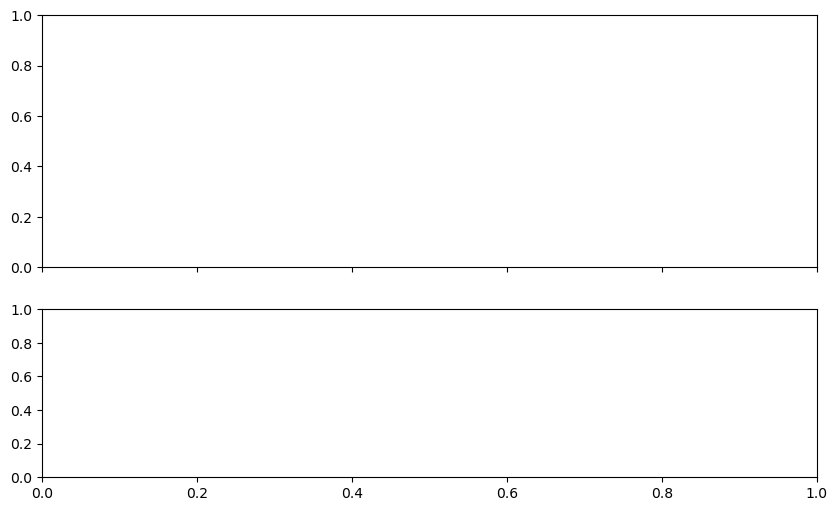

In [16]:
# Roman sensitivity in θE units
thetaE_mas = theta_E_mas
roman_sensitivity = 0.01 / thetaE_mas   # 10 µas = 0.01 mas

fig, axes = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True,
    gridspec_kw={'height_ratios': [3, 2]}  # top 3x taller than bottom
)

# --- Top panel: centroid shifts ---
axes[0].plot(triple_model_tau, delta_double_B,'k-', label="2S: Star & Planet")
axes[0].plot(triple_model_tau, delta_double_A, 'b--', label="2S: Star & (Planet + Moon)")
axes[0].plot(triple_model_tau, delta_triple, 'g--', label="3S: Star, Planet & Moon")
axes[0].set_ylabel("Centroid shift (θE)")
axes[0].set_title("Centroid Shifts")
axes[0].legend()

# --- Bottom panel: residuals ---
axes[1].plot(triple_model_tau, res_triple, 'g--', label="Triple residual")
axes[1].plot(triple_model_tau, res_double, 'b--', label="Double residual")
axes[1].axhline(roman_sensitivity, color="red", linestyle="--", label="Roman's Sensitivity")
axes[1].axhline(-roman_sensitivity, color="red", linestyle="--")
axes[1].set_xlabel(r"$\tau$")
axes[1].set_ylabel("Residual (θE units)")
axes[1].set_title("Residuals")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
||